In [1]:
library(tidyverse)
library(stringr)
library(readr)
library(fs)


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.3     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.4.4     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.0
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [12]:
data.2014 <- read_csv("..//data/output/data-2014.csv")
data.2015 <- read_csv("..//data/output/data-2015.csv")
data.2016 <- read_csv("..//data/output/data-2016.csv")
data.2017 <- read_csv("..//data/output/data-2017.csv")
data.2018 <- read_csv("..//data/output/data-2018.csv")
data.2019 <- read_csv("..//data/output/data-2019.csv")

Rows: 62344 Columns: 61
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (16): contractid, state, county, org_type, plan_type, partd, snp, eghp, ...
dbl (45): planid, fips, year.x, n_nonmiss, avg_enrollment, sd_enrollment, mi...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 65499 Columns: 61
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (16): contractid, state, county, org_type, plan_type, partd, snp, eghp, ...
dbl (45): planid, fips, year.x, n_nonmiss, avg_enrollment, sd_enrollment, mi...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 68774 Columns: 61
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (16): 

In [13]:
combined <- bind_rows(
  data.2014,
  data.2015,
  data.2016,
  data.2017,
  data.2018,
  data.2019
)

In [14]:
glimpse(combined)

Rows: 449,046
Columns: 61
$ contractid          <chr> "H0022", "H0022", "H0022", "H0022", "H0022", "H002…
$ planid              <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4,…
$ fips                <dbl> 39023, 39035, 39051, 39055, 39057, 39085, 39093, 3…
$ year.x              <dbl> 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 20…
$ n_nonmiss           <dbl> 6, 8, 7, 0, 6, 8, 8, 7, 8, 6, 4, 7, 12, 12, 12, 12…
$ avg_enrollment      <dbl> 72.00000, 330.12500, 24.57143, NA, 120.83333, 41.5…
$ sd_enrollment       <dbl> 7.2111026, 10.6158574, 1.8126539, NA, 15.7659972, …
$ min_enrollment      <dbl> 60, 309, 23, NA, 90, 39, 29, 299, 24, 431, 11, 71,…
$ max_enrollment      <dbl> 81, 344, 28, NA, 135, 44, 43, 440, 26, 713, 12, 85…
$ first_enrollment    <dbl> 60, 309, 24, NA, 90, 41, 29, 299, 24, 431, 11, 71,…
$ last_enrollment     <dbl> 81, 344, 24, NA, 135, 44, 43, 440, 24, 713, 12, 82…
$ state               <chr> "OH", "OH", "OH", "OH", "OH", "OH", "OH", "OH", "O…
$ county      

Problem 1

In [35]:
plan_counts <- combined %>% 
group_by(fips, contractid, year.x)%>% 
count(county, year.x, name = "plan_count")

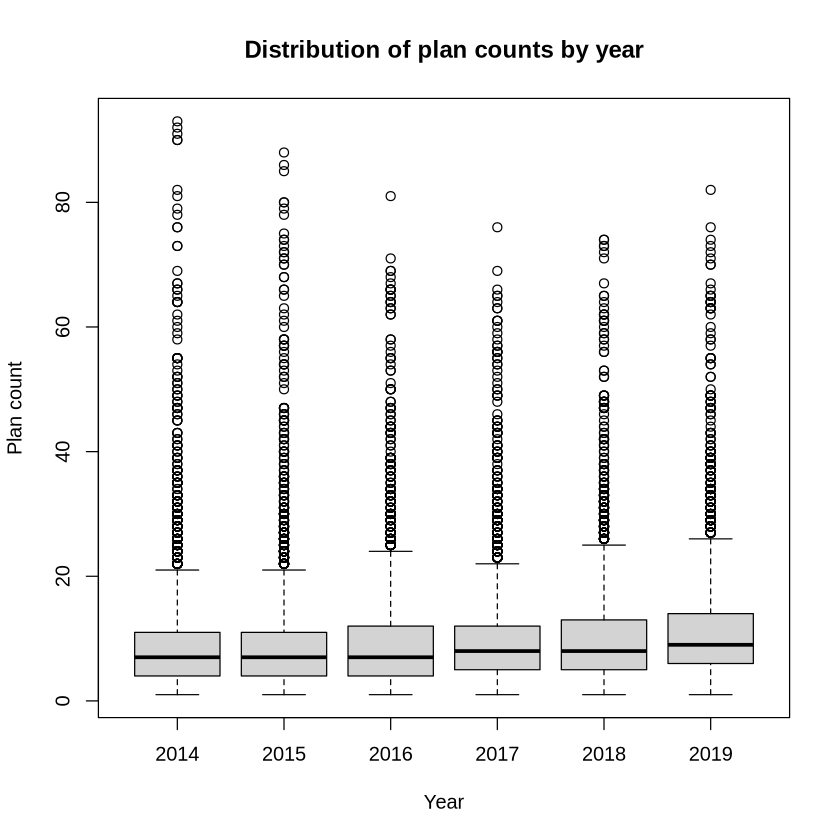

In [39]:
boxplot(plan_count ~ year.x, data = plan_counts,
        xlab = "Year",
        ylab = "Plan count",
        main = "Distribution of plan counts by year" )

In [17]:
combined <- combined %>% mutate (basic_premium = case_when(
        rebate_partc > 0 ~ 0,
        partd == "No" & !is.na(premium) & is.na(premium_partc) ~ premium,
        TRUE ~ premium_partc
      ),
      bid = case_when(
        rebate_partc == 0 & basic_premium > 0 ~ (payment_partc + basic_premium) / riskscore_partc,
        rebate_partc > 0  | basic_premium == 0 ~  payment_partc / riskscore_partc,
        TRUE ~ NA_real_
      )
                                 )

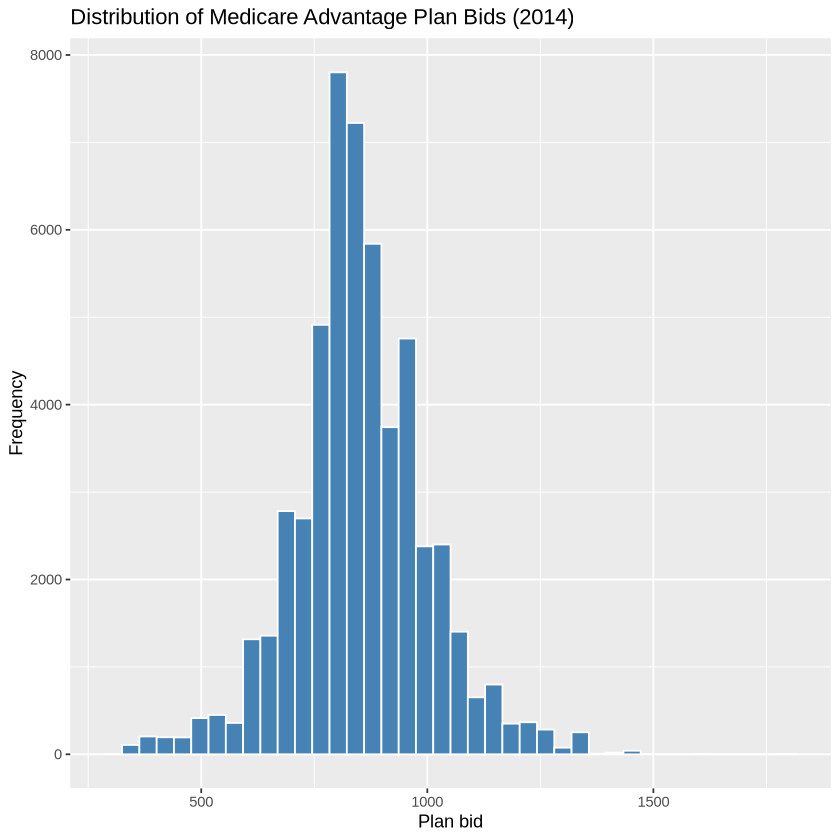

In [18]:
ggplot(filter(combined, year.x == 2014, !is.na(bid)), aes(x = bid)) +
  geom_histogram(bins = 40, fill = "steelblue", color = "white") +
  labs(
    title = "Distribution of Medicare Advantage Plan Bids (2014)",
    x = "Plan bid",
    y = "Frequency"
  ) 

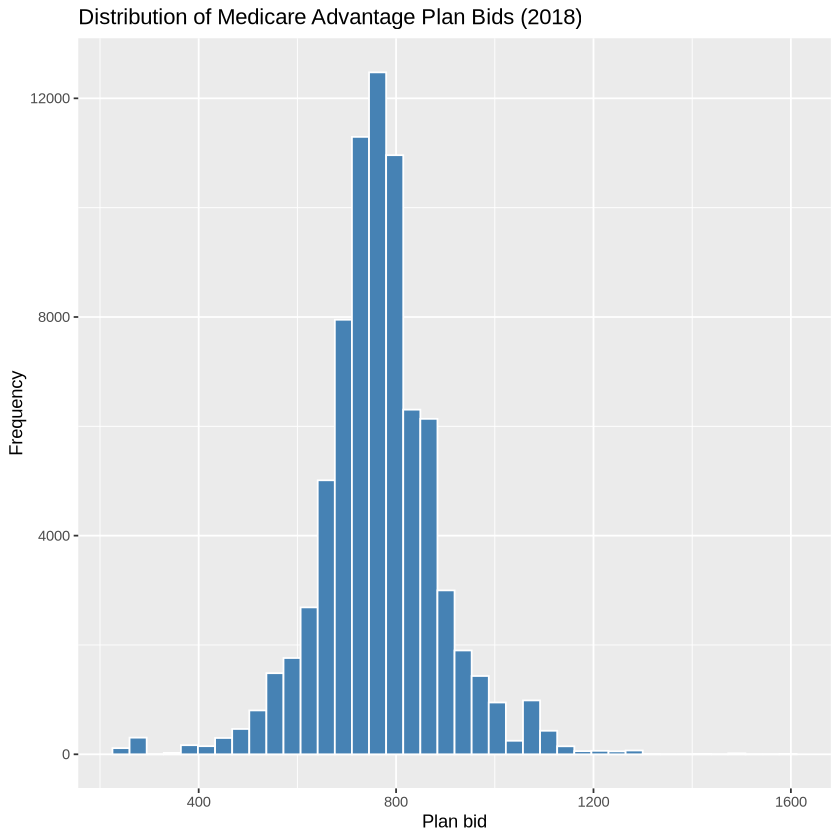

In [19]:
ggplot(filter(combined, year.x == 2018, !is.na(bid)), aes(x = bid)) +
  geom_histogram(bins = 40, fill = "steelblue", color = "white") +
  labs(
    title = "Distribution of Medicare Advantage Plan Bids (2018)",
    x = "Plan bid",
    y = "Frequency"
  ) 

Problem 3

In [20]:
combined_hhi <- combined %>%
  filter(!is.na(avg_enrolled), avg_enrolled > 0) %>%
  filter(!is.na(avg_enrollment), avg_enrollment > 0) %>%
  group_by(fips, year.x) %>%
  mutate(market_share = avg_enrollment / avg_enrolled
  ) %>%
  ungroup()


In [21]:
county_hhi <- combined_hhi %>%
  group_by(fips, year.x) %>%
  summarise(
    hhi = sum(market_share^2),
    .groups = "drop"
  )

In [22]:
avg_hhi <- county_hhi %>%
  group_by(year.x) %>%
  summarise(
    avg_hhi = mean(hhi),
    .groups = "drop"
  )

In [23]:
avg_hhi

year.x,avg_hhi
<dbl>,<dbl>
2014,0.1826015
2015,0.1778957
2016,0.1772325
2017,0.1665723
2018,0.1457807
2019,0.1256304


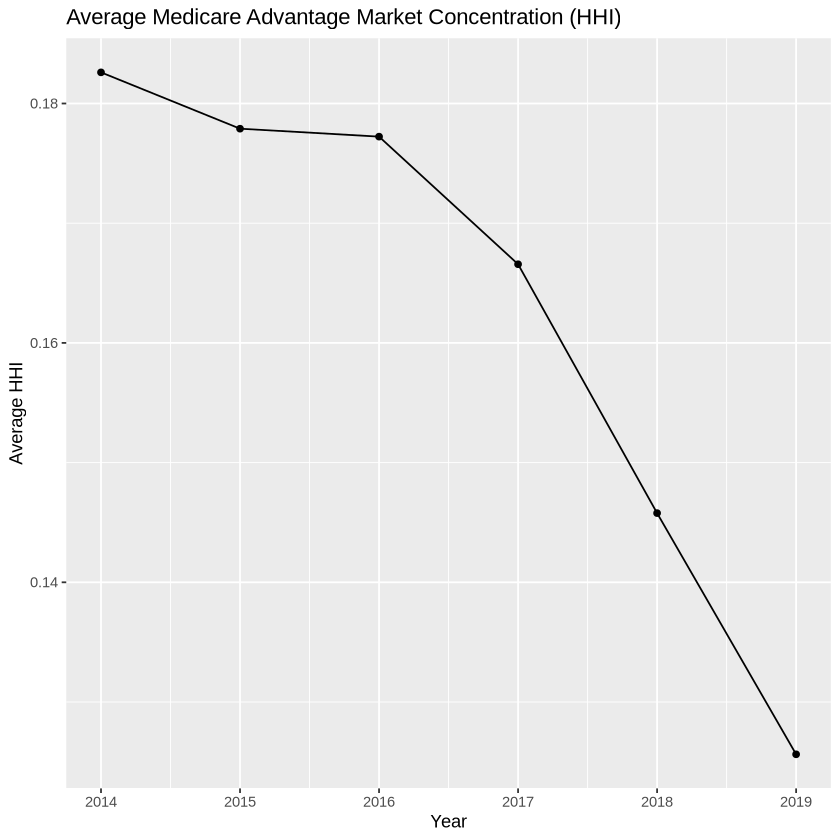

In [24]:
ggplot(avg_hhi, aes(x = year.x, y = avg_hhi)) +
  geom_line() +
  geom_point() +
  labs(
    title = "Average Medicare Advantage Market Concentration (HHI)",
    x = "Year",
    y = "Average HHI"
  )

Problem 4

In [25]:
ma_year <- combined %>%
  group_by(year.x) %>%
    mutate(ma_share = avg_enrolled / avg_eligibles) %>%
    summarise(mean = mean(ma_share, na.rm=TRUE), groups = "drop")

In [26]:
ma_year

year.x,mean,groups
<dbl>,<dbl>,<chr>
2014,0.2838786,drop
2015,0.2976222,drop
2016,0.3040652,drop
2017,0.3169226,drop
2018,0.3256874,drop
2019,0.3533356,drop


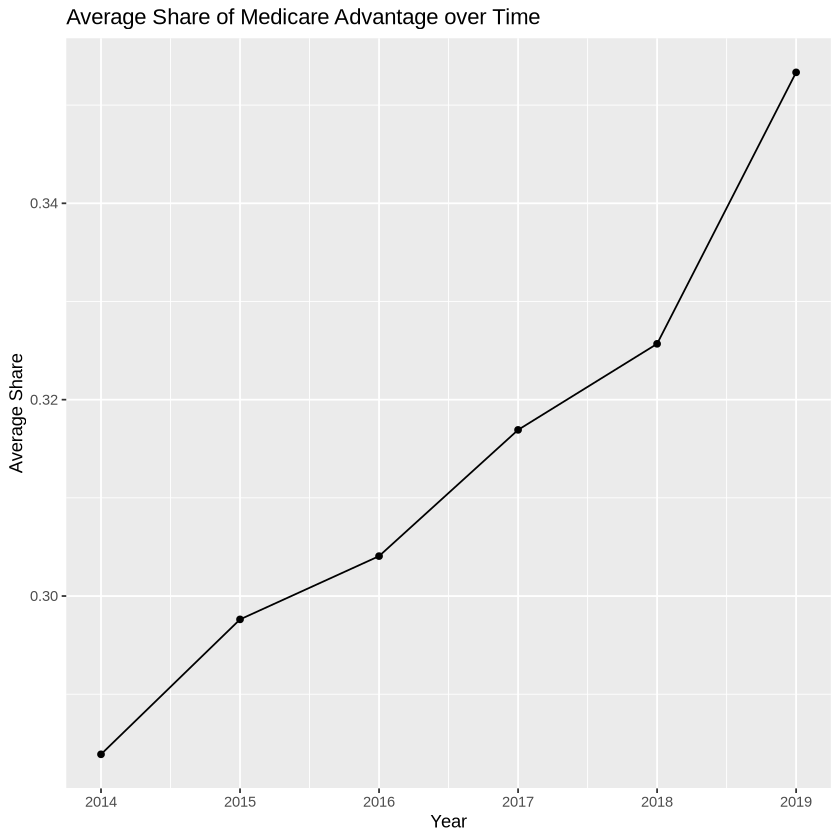

In [27]:
ggplot(ma_year, aes(x = year.x, y = mean)) +
  geom_line() +
  geom_point() +
  labs(
    title = "Average Share of Medicare Advantage over Time",
    x = "Year",
    y = "Average Share"
  )

In [28]:
glimpse(data.2018)

Rows: 85,866
Columns: 61
$ contractid          <chr> "H0022", "H0022", "H0022", "H0022", "H0022", "H002…
$ planid              <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 4, 4, 4, 8, 8,…
$ fips                <dbl> 39023, 39035, 39051, 39055, 39057, 39085, 39093, 3…
$ year.x              <dbl> 2018, 2018, 2018, 2018, 2018, 2018, 2018, 2018, 20…
$ n_nonmiss           <dbl> 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12…
$ avg_enrollment      <dbl> 598.41667, 3653.00000, 115.83333, 77.33333, 571.08…
$ sd_enrollment       <dbl> 23.592982, 92.164872, 6.873312, 4.658001, 24.39619…
$ min_enrollment      <dbl> 558, 3549, 107, 68, 539, 278, 531, 2776, 180, 3115…
$ max_enrollment      <dbl> 638, 3829, 126, 84, 618, 341, 591, 3006, 217, 3351…
$ first_enrollment    <dbl> 558, 3596, 107, 80, 539, 278, 559, 2782, 192, 3128…
$ last_enrollment     <dbl> 622, 3657, 126, 80, 601, 324, 535, 2892, 205, 3278…
$ state               <chr> "OH", "OH", "OH", "OH", "OH", "OH", "OH", "OH", "O…
$ county       

Problem 5

In [21]:
marketshare2018 <- data.2018 %>%
  filter(!is.na(avg_enrolled), avg_enrolled > 0) %>%
  filter(!is.na(avg_enrollment), avg_enrollment > 0) %>%
  group_by(fips, year.x) %>%
  mutate(market_share = avg_enrollment / avg_enrolled
  ) %>%
  ungroup()


In [22]:
hhi_2018 <- marketshare2018 %>%
  group_by(fips) %>%
  mutate(
    hhi = sum(market_share^2, na.rm = TRUE),
  )%>%
  ungroup()

In [23]:
glimpse(hhi_2018)

Rows: 29,138
Columns: 63
$ contractid          <chr> "H0022", "H0022", "H0022", "H0022", "H0022", "H002…
$ planid              <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 4, 4, 4, 8, 8,…
$ fips                <dbl> 39023, 39035, 39051, 39055, 39057, 39085, 39093, 3…
$ year.x              <dbl> 2018, 2018, 2018, 2018, 2018, 2018, 2018, 2018, 20…
$ n_nonmiss           <dbl> 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12…
$ avg_enrollment      <dbl> 598.41667, 3653.00000, 115.83333, 77.33333, 571.08…
$ sd_enrollment       <dbl> 23.592982, 92.164872, 6.873312, 4.658001, 24.39619…
$ min_enrollment      <dbl> 558, 3549, 107, 68, 539, 278, 531, 2776, 180, 3115…
$ max_enrollment      <dbl> 638, 3829, 126, 84, 618, 341, 591, 3006, 217, 3351…
$ first_enrollment    <dbl> 558, 3596, 107, 80, 539, 278, 559, 2782, 192, 3128…
$ last_enrollment     <dbl> 622, 3657, 126, 80, 601, 324, 535, 2892, 205, 3278…
$ state               <chr> "OH", "OH", "OH", "OH", "OH", "OH", "OH", "OH", "O…
$ county       

In [24]:
hhi_33 <- quantile(hhi_2018$hhi, 0.33, na.rm = TRUE)
hhi_66 <- quantile(hhi_2018$hhi, 0.66, na.rm = TRUE)

In [25]:
hhi_2018 <- hhi_2018 %>%
  mutate(
    market_type = case_when(
      hhi <= hhi_33 ~ "Competitive",
      hhi >= hhi_66 ~ "Uncompetitive",
      TRUE ~ NA_character_
    )
  )

In [26]:
avg_bid_by_market <- hhi_2018 %>%
  filter(!is.na(market_type), !is.na(bid)) %>%
  group_by(market_type) %>%
  summarise(
    avg_bid = mean(bid),
    .groups = "drop"
  )

In [27]:
print(avg_bid_by_market)

# A tibble: 2 × 2
  market_type   avg_bid
  <chr>           <dbl>
1 Competitive      778.
2 Uncompetitive    771.


Problem 6

In [28]:
ffs.2018 <- read_csv("..//data/output/data-2018-ffs.csv")

Rows: 85866 Columns: 68
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (17): contractid, state, county, org_type, plan_type, partd, snp, eghp, ...
dbl (50): planid, fips, year, n_nonmiss, avg_enrollment, sd_enrollment, min_...
lgl  (1): mean_risk

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [29]:
colnames(ffs.2018)

[1] "contractid"          "planid"              "fips"               
 [4] "year"                "n_nonmiss"           "avg_enrollment"     
 [7] "sd_enrollment"       "min_enrollment"      "max_enrollment"     
[10] "first_enrollment"    "last_enrollment"     "state"              
[13] "county"              "org_type"            "plan_type"          
[16] "partd"               "snp"                 "eghp"               
[19] "org_name"            "org_marketing_name"  "plan_name"          
[22] "parent_org"          "contract_date"       "state_long"         
[25] "county_long"         "year.y"              "n_elig"             
[28] "n_enrol"             "avg_eligibles"       "sd_eligibles"       
[31] "min_eligibles"       "max_eligibles"       "first_eligibles"    
[34] "last_eligibles"      "avg_enrolled"        "sd_enrolled"        
[37] "min_enrolled"        "max_enrolled"        "first_enrolled"     
[40] "last_enrolled"       "ssa"                 "ncount"             
[43] "state_name"          "premium"             "premium_partc"      
[46] "premium_partd_basic" "premium_partd_supp"  "premium_partd_total"
[49] "partd_deductible"    "year.x.x"            "riskscore_partc"    
[52] "payment_partc"       "rebate_partc"        "year.y.y"           
[55] "payment_partd"       "directsubsidy_partd" "reinsurance_partd"  
[58] "costsharing_partd"   "riskscore_partd"     "basic_premium"      
[61] "bid"                 "county_name"         "parta_enroll"       
[64] "parta_reimb"         "partb_enroll"        "partb_reimb"        
[67] "mean_risk"           "avg_ffscost"

In [30]:
ffs.2018 <- ffs.2018 %>%
  mutate(
    ffscost_q = ntile(avg_ffscost, 4)
  )

In [31]:
q1 <- ffs.2018 %>%
  mutate(treated = if_else(ffscost_q == 1, "Treated", "Control")) %>%
  group_by(treated) %>%
  summarise(avg_bid = mean(bid, na.rm = TRUE), n = n(), .groups = "drop") %>%
  mutate(quartile = "Q1")

q2 <- ffs.2018 %>%
  mutate(treated = if_else(ffscost_q == 2, "Treated", "Control")) %>%
  group_by(treated) %>%
  summarise(avg_bid = mean(bid, na.rm = TRUE), n = n(), .groups = "drop") %>%
  mutate(quartile = "Q2")

q3 <- ffs.2018 %>%
  mutate(treated = if_else(ffscost_q == 3, "Treated", "Control")) %>%
  group_by(treated) %>%
  summarise(avg_bid = mean(bid, na.rm = TRUE), n = n(), .groups = "drop") %>%
  mutate(quartile = "Q3")

q4 <- ffs.2018 %>%
  mutate(treated = if_else(ffscost_q == 4, "Treated", "Control")) %>%
  group_by(treated) %>%
  summarise(avg_bid = mean(bid, na.rm = TRUE), n = n(), .groups = "drop") %>%
  mutate(quartile = "Q4")

In [32]:
big_avg_table <- bind_rows(q1, q2, q3, q4) %>%
  select(quartile, treated, avg_bid, n)

big_avg_table

quartile,treated,avg_bid,n
<chr>,<chr>,<dbl>,<int>
Q1,Control,761.3458,64355
Q1,Treated,778.7275,21452
Q1,NA,823.8797,59
Q2,Control,764.2578,64355
Q2,Treated,769.9289,21452
Q2,NA,823.8797,59
Q3,Control,768.2317,64355
Q3,Treated,758.0963,21452
Q3,NA,823.8797,59


Problem 7

In [33]:
options(repos = c(CRAN = "https://cran.rstudio.com/"))
install.packages("MatchIt")

Installing package into ‘/home/ski2983/R/x86_64-conda-linux-gnu-library/4.3’
(as ‘lib’ is unspecified)



In [34]:
ate_results <- lapply(1:4, function(q) {

dat_q <- ffs.2018 %>%
    mutate(
      treat = ifelse(ffscost_q == q, 1, 0),
      outcome = bid,
      covar = avg_ffscost
    )

dat_q <- dat_q %>% 
  filter(!is.na(outcome), !is.na(treat), !is.na(covar))

nn2 <- Matching::Match(
    Y = dat_q$outcome,
    Tr = dat_q$treat,
    X = dat_q$covar,
    M = 1,
    Weight = 1,
    estimand = "ATE",
    ties=FALSE
  )

  data.frame(
    quartile = q,
    ATE = nn2$est
  )
})

ate_table <- do.call(rbind, ate_results)

print(ate_table)

  quartile       ATE
1        1 -97.16771
2        2  14.48494
3        3  41.17377
4        4 -27.79567


In [55]:
print(ate_table)

  quartile       ATE
1        1 -97.16771
2        2  14.48494
3        3  41.17377
4        4 -27.79567


In [44]:
ate_results <- lapply(1:4, function(q) {

dat_q <- ffs.2018 %>%
    mutate(
      treat = ifelse(ffscost_q == q, 1, 0),
      outcome = bid,
      covar = avg_ffscost
    )

dat_q <- dat_q %>% 
  filter(!is.na(outcome), !is.na(treat), !is.na(covar))

nn2 <- Matching::Match(
    Y = dat_q$outcome,
    Tr = dat_q$treat,
    X = dat_q$covar,
    M = 1,
    Weight = 2,
    estimand = "ATE",
    ties=FALSE
  )

  data.frame(
    quartile = q,
    ATE = nn2$est
  )
})

ate_table_2 <- do.call(rbind, ate_results)

print(ate_table_2)

  quartile       ATE
1        1 -97.73672
2        2  14.56085
3        3  41.31849
4        4 -28.11208


In [52]:
print(ate_table_2)

  quartile       ATE
1        1 -97.73672
2        2  14.56085
3        3  41.31849
4        4 -28.11208


In [46]:
ate_results <- lapply(1:4, function(q) {

  dat_q <- ffs.2018 %>%
    mutate(
      w = ifelse(ffscost_q == q, 1, 0),   
      y = bid,
      x = ffscost_q                      
    ) %>%
    filter(!is.na(y), !is.na(w), !is.na(x))

  logit.model <- glm(w ~ factor(x), family = binomial, data = dat_q)
  ps <- fitted(logit.model)

  dat_q <- dat_q %>%
    mutate(ipw = case_when(
      w == 1 ~ 1 / ps,
      w == 0 ~ 1 / (1 - ps),
      TRUE ~ NA_real_
    ))

  mean.w1 <- dat_q %>%
    filter(w == 1) %>%
    summarise(mean_y = weighted.mean(y, ipw))

  mean.w0 <- dat_q %>%
    filter(w == 0) %>%
    summarise(mean_y = weighted.mean(y, ipw))

  data.frame(
    quartile = q,
    ATE_IPW = mean.w1$mean_y - mean.w0$mean_y
  )
})

ate_table_ipw <- do.call(rbind, ate_results)
print(ate_table_ipw)


Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”


  quartile    ATE_IPW
1        1  17.381757
2        2   5.671065
3        3 -10.135400
4        4 -12.776548


In [53]:
print(ate_table_ipw)

  quartile    ATE_IPW
1        1  17.381757
2        2   5.671065
3        3 -10.135400
4        4 -12.776548


In [48]:
ate_results_reg <- lapply(1:4, function(q) {

  select.dat <- ffs.2018 %>%
    mutate(
      w = ifelse(ffscost_q == q, 1, 0),
      y = bid,
      x = ffscost_q
    ) %>%
    filter(!is.na(y), !is.na(w), !is.na(x))

  reg <- lm(y ~ w * factor(x), data = select.dat)

  pred1 <- predict(reg, newdata = transform(select.dat, w = 1))
  pred0 <- predict(reg, newdata = transform(select.dat, w = 0))

  ate <- mean(pred1 - pred0, na.rm = TRUE)

  data.frame(
    quartile = q,
    ATE_regression = ate
  )
})

ate_table_reg <- do.call(rbind, ate_results_reg)
print(ate_table_reg)


Warning message in predict.lm(reg, newdata = transform(select.dat, w = 1)):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(reg, newdata = transform(select.dat, w = 0)):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(reg, newdata = transform(select.dat, w = 1)):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(reg, newdata = transform(select.dat, w = 0)):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(reg, newdata = transform(select.dat, w = 1)):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(reg, newdata = transform(select.dat, w = 0)):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(reg, newdata = transform(select.dat, w = 1)):


  quartile ATE_regression
1        1      22.646089
2        2      -8.798631
3        3     -20.631194
4        4     -22.646089


In [54]:
print(ate_table_reg)

  quartile ATE_regression
1        1      22.646089
2        2      -8.798631
3        3     -20.631194
4        4     -22.646089


In [49]:
saveRDS(ate_table_reg, "ate_table_reg.rds")

Problem 8

Nearest neighbor matching with inverse variance distance and with Mahalanobis distance have very similar average treatment effect values. However, when using inverse propensity weighting and simple linear regression, both methods output noticeably different values. 

Problem 9

In [50]:
ate_results_reg_cont <- lapply(1:4, function(q) {

  select.dat <- ffs.2018 %>%
    mutate(
      w = ifelse(ffscost_q == q, 1, 0),
      y = bid,
      x1 = avg_ffscost,
      x2 = n_enrol
    ) %>%
    filter(!is.na(y), !is.na(w), !is.na(x1), !is.na(x2))

  reg <- lm(y ~ w * (x1 + x2), data = select.dat)

  pred1 <- predict(reg, newdata = transform(select.dat, w = 1))
  pred0 <- predict(reg, newdata = transform(select.dat, w = 0))

  ate <- mean(pred1 - pred0, na.rm = TRUE)

  data.frame(
    quartile = q,
    ATE_regression_continuous = ate
  )
})

ate_table_reg_cont <- do.call(rbind, ate_results_reg_cont)
print(ate_table_reg_cont)


  quartile ATE_regression_continuous
1        1                -9.4984154
2        2                -0.1257976
3        3                -7.3484978
4        4                -2.7936440


In [56]:
print(ate_table_reg_cont)

  quartile ATE_regression_continuous
1        1                -9.4984154
2        2                -0.1257976
3        3                -7.3484978
4        4                -2.7936440


Problem 10

Working with this data allowed me to see how different estimators will give you vastly different values. One thing that I learned was that it is crucial to know what each name of the row represents so that there is no issue missing a part of the dataset. One thing that surprised me was how easy it was for library or model choices to cause errors or slow runtimes.